# Notebook 04 — Fine-Tuned DistilBERT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Switch to GPU if present
import torch

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.randn(5, 5).to(device)
print(x.device)


True
cuda:0


In [3]:
import sys, os
import sys
sys.path.append('/content/drive/MyDrive/spoiler-detection-nlp')

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from peft import LoraConfig, get_peft_model, TaskType
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm import tqdm

from src.config import (
    MODELS_DIR, RANDOM_SEED
)
from src.data_loader import load_reviews, create_splits
from src.evaluation import (
    compute_metrics, save_results,
    plot_confusion_matrix, plot_roc_curve,
    print_classification_report,
)

torch.manual_seed(RANDOM_SEED)

## 1 · Load & Split Data

In [4]:
BERT_SAMPLE_SIZE = 100_000
print(f'Loading {BERT_SAMPLE_SIZE:,}')
df = load_reviews(sample_size=BERT_SAMPLE_SIZE)

train_df, val_df, test_df = create_splits(df)

print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')
print(f'Test  : {len(test_df):,}')

Loading 100,000
Train : 70,000
Val   : 10,000
Test  : 20,000


## 2 · Tokenization

In [5]:
BERT_MODEL_NAME = "distilbert-base-uncased"
BERT_MAX_LENGTH = 512
BERT_BATCH_SIZE = 32
BERT_LEARNING_RATE = 2e-5
BERT_EPOCHS = 3
BERT_WARMUP_STEPS = 500
BERT_WEIGHT_DECAY = 0.01

In [6]:
class SpoilerDataset(Dataset):
    """PyTorch Dataset for spoiler classification."""

    def __init__(self, texts, labels, tokenizer, max_length=BERT_MAX_LENGTH):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [7]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

train_dataset = SpoilerDataset(train_df['review_text'].tolist(), train_df['label'].values, tokenizer)
val_dataset   = SpoilerDataset(val_df['review_text'].tolist(), val_df['label'].values, tokenizer)
test_dataset  = SpoilerDataset(test_df['review_text'].tolist(), test_df['label'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BERT_BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BERT_BATCH_SIZE)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 2188
Val batches  : 313
Test batches : 625


## 3 · Model Setup

In [8]:
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_lin", "v_lin"]

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2,
).to(device)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
)

model = get_peft_model(model, peft_config)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BERT_LEARNING_RATE,
    weight_decay=BERT_WEIGHT_DECAY,
)

total_steps = len(train_loader) * BERT_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=BERT_WARMUP_STEPS,
    num_training_steps=total_steps,
)

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

trainable, total = count_parameters(model)
print(f'Total parameters: {total:,}')
print(f'Trainable parameters: {trainable:,} ({100 * trainable / total:.2f}%)')
print(f'Total training steps: {total_steps:,}')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 67,842,052
Trainable parameters: 887,042 (1.31%)
Total training steps: 6,564


## 4 · Training Loop

In [12]:
def evaluate(model, loader, device):
    """Run evaluation and return loss, predictions, probabilities."""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                          attention_mask=attention_mask,
                          labels=labels)

            total_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [13]:

best_val_f1 = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

total_train_time = 0

for epoch in range(BERT_EPOCHS):
    model.train()
    epoch_loss = 0
    t = time.time()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{BERT_EPOCHS}')
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_time = time.time() - t
    total_train_time += epoch_time
    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, device)
    val_metrics = compute_metrics(val_labels, val_preds, val_probs)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_metrics['f1'])

    print(f'\nEpoch {epoch+1} ({epoch_time:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val F1: {val_metrics["f1"]:.4f} | '
          f'Val Acc: {val_metrics["accuracy"]:.4f}')

    # Save best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        save_path = os.path.join(MODELS_DIR, 'distilbert_best')
        model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print(f'Best model saved (F1={best_val_f1:.4f})')

print(f'\nTraining complete — Total time: {total_train_time:.0f}s')
print(f'Best Val F1: {best_val_f1:.4f}')

Epoch 1/3: 100%|██████████| 2188/2188 [19:48<00:00,  1.84it/s, loss=0.4602]



Epoch 1 (1189s) | Train Loss: 0.5202 | Val Loss: 0.4990 | Val F1: 0.3477 | Val Acc: 0.7670
Best model saved (F1=0.3477)


Epoch 2/3: 100%|██████████| 2188/2188 [19:49<00:00,  1.84it/s, loss=0.7250]



Epoch 2 (1190s) | Train Loss: 0.4866 | Val Loss: 0.4858 | Val F1: 0.4274 | Val Acc: 0.7680
Best model saved (F1=0.4274)


Epoch 3/3: 100%|██████████| 2188/2188 [19:49<00:00,  1.84it/s, loss=0.3756]



Epoch 3 (1190s) | Train Loss: 0.4799 | Val Loss: 0.4830 | Val F1: 0.3982 | Val Acc: 0.7739

Training complete — Total time: 3568s
Best Val F1: 0.4274


## 5 · Training Curves

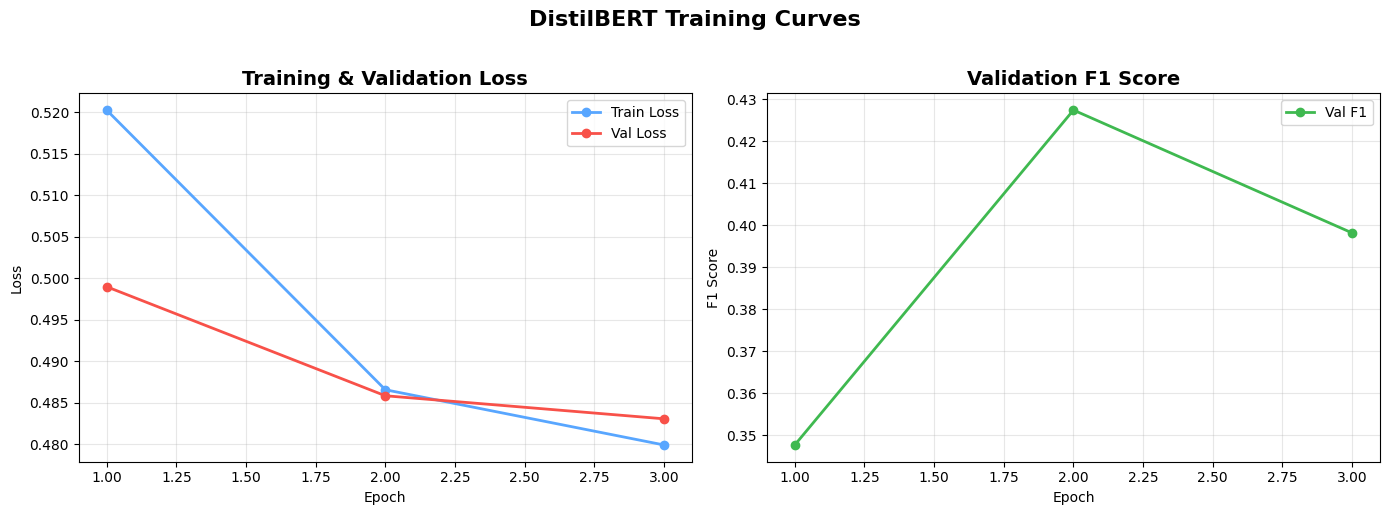

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, BERT_EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#58a6ff',
             linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'o-', color='#f85149',
             linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1
axes[1].plot(epochs_range, history['val_f1'], 'o-', color='#3fb950',
             linewidth=2, label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1 Score', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DistilBERT Training Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

import os

RESULTS_DIR = "/content/drive/MyDrive/spoiler-detection-nlp/results/BERT"
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.savefig(f"{RESULTS_DIR}/distilbert_training_curves.png", dpi=150, bbox_inches='tight')

plt.show()

## 6 · Test Evaluation

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== DistilBERT (test) ===
              precision    recall  f1-score   support

 Non-Spoiler       0.80      0.93      0.86     14741
     Spoiler       0.64      0.34      0.44      5259

    accuracy                           0.78     20000
   macro avg       0.72      0.63      0.65     20000
weighted avg       0.76      0.78      0.75     20000

Confusion matrix saved → /content/drive/MyDrive/spoiler-detection-nlp/results/model_charts/distilbert_cm.png


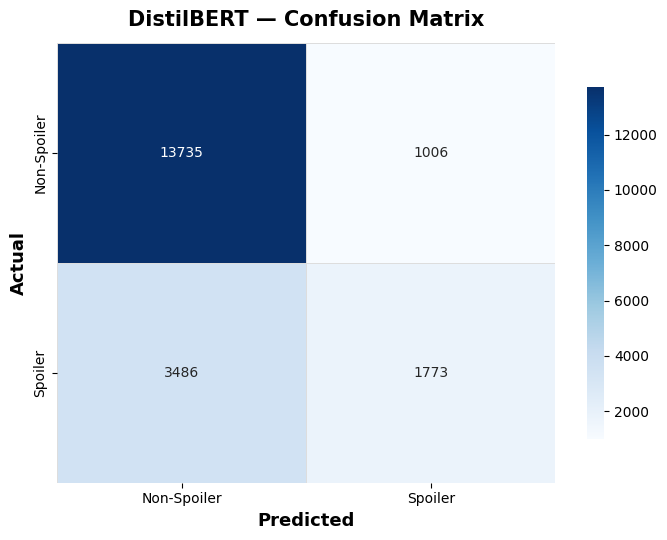

ROC curve saved → /content/drive/MyDrive/spoiler-detection-nlp/results/model_charts/distilbert_roc.png


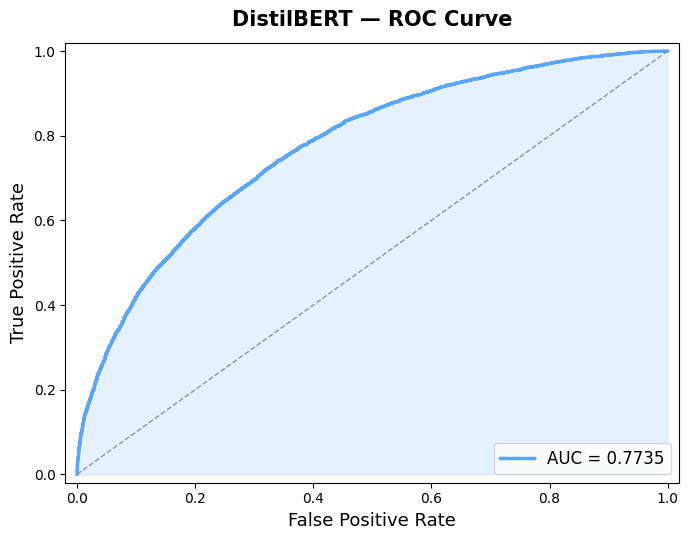

Results saved → /content/drive/MyDrive/spoiler-detection-nlp/results/model_results/distilbert.json


'/content/drive/MyDrive/spoiler-detection-nlp/results/model_results/distilbert.json'

In [19]:
# Load best model
from transformers import AutoModelForSequenceClassification
from peft import PeftModel
import os

# Load base model with correct architecture
base_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2  # IMPORTANT: match your training setup
)

# Attach trained LoRA adapter
best_model = PeftModel.from_pretrained(
    base_model,
    os.path.join(MODELS_DIR, "distilbert_best")
)

best_model = best_model.to(device)
best_model.eval()

test_loss, test_preds, test_labels, test_probs = evaluate(best_model, test_loader, device)

metrics_bert = compute_metrics(test_labels, test_preds, test_probs)

print('=== DistilBERT (test) ===')
print_classification_report(test_labels, test_preds)

plot_confusion_matrix(test_labels, test_preds,
                      title='DistilBERT — Confusion Matrix',
                      save_name='distilbert')

plot_roc_curve(test_labels, test_probs,
               title='DistilBERT — ROC Curve',
               save_name='distilbert')

save_results('distilbert', metrics_bert,
             extra={
                 'model_name': BERT_MODEL_NAME,
                 'max_length': BERT_MAX_LENGTH,
                 'batch_size': BERT_BATCH_SIZE,
                 'learning_rate': BERT_LEARNING_RATE,
                 'epochs': BERT_EPOCHS,
                 'warmup_steps': BERT_WARMUP_STEPS,
                 'weight_decay': BERT_WEIGHT_DECAY,
                 'sample_size': BERT_SAMPLE_SIZE,
                 'training_time_seconds': round(total_train_time, 2),
                 'best_val_f1': best_val_f1,
                 'training_history': history,
             })

## Summary

| Metric    | Value |

| :---      | :---  |

| Accuracy  | 0.7754 |

| Precision | 0.6379992803166606|

| Recall    |0.33713633770678836 |

| F1-Score  | 0.4411545160487684 |

| ROC-AUC   |0.7735467558955049 |



### Training Details

- **Model**: `distilbert-base-uncased` with **LoRA**

- **Trainable Params**: ~600k (< 2%)

- **Sample Size**: 100,000 stratified reviews

- **Results**: Saved to `results/model_results/distilbert.json`
